Download and use the cleaned dataset from the drive link:https://drive.google.com/file/d/1g7Ptw8JZ9d_Kp9cFYnci-L2_E5GwwtVR/view?usp=sharing

kaggle dataset link: https://www.kaggle.com/datasets/shivamb/netflix-shows?resource=download


**Business and Data Visualization Context**

**Objective**:
This analysis aims to analyse Netflix’s content dataset to discover important patterns in areas such as content type, genre, duration time, and release trends. The key reason is to understand how Netflix organizes its content and how these patterns can help future content decisions. By identifying these key insights, the analysis helps in making more informed and data-based solutions.

**Target Audience**:
The target audience for this analysis is Netflix’s content strategy team and other important decision-makers within the organisation. These members of the team are responsible for executing content production, selecting suitable genres, and identifying opportunities for development in different areas. The insights from this analysis can help them make more effective and good decisions.

**Use of Data Visualization**:
Data visualization here is used to present the analysis in a clean and more organised way. Different types of charts are used to highlight trends, compare different categories, and show distributions within the given data. This method makes it easier to understand the results and extract key findings in a simple and visual appealing method.

**Data Overview**:
The dataset includes information about Netflix movies and TV shows, such as content title, content category, country, release time, date added, genre, ratings, and duration. This contains both categorical and numerical variables, which makes it possible to analyse different areas of the data. This allows for a better understanding of content patterns and how they relate to Netflix’s overall planning.




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['axes.titleweight'] = 'bold'

main_color = "#E50914"
secondary_color = "#4B4B4B"

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('Data VS - netflix_titles.csv')
df.head()

Saving Data VS - netflix_titles.csv to Data VS - netflix_titles (7).csv


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,jonny smith,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,aa,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",India,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,aa,vineeth,India,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,aa,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Data Understanding

The dataset contains information on Netflix titles including type, country, release year, duration, and genre.

Key issues identified:
- Missing values in country and director
- Mixed format in duration column (minutes vs seasons)
- Date formatting inconsistencies

In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8797 entries, 0 to 8796
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   8797 non-null   object
 1   Unnamed: 1   8797 non-null   object
 2   Unnamed: 2   8797 non-null   object
 3   Unnamed: 3   8797 non-null   object
 4   Unnamed: 4   8797 non-null   object
 5   Unnamed: 5   8797 non-null   object
 6   Unnamed: 6   8797 non-null   object
 7   Unnamed: 7   8797 non-null   int64 
 8   Unnamed: 8   8797 non-null   object
 9   Unnamed: 9   8797 non-null   object
 10  Unnamed: 10  8797 non-null   object
 11  Unnamed: 11  8797 non-null   object
dtypes: int64(1), object(11)
memory usage: 824.8+ KB


,0
Unnamed: 0,0
Unnamed: 1,0
Unnamed: 2,0
Unnamed: 3,0
Unnamed: 4,0
Unnamed: 5,0
Unnamed: 6,0
Unnamed: 7,0
Unnamed: 8,0
Unnamed: 9,0


Data Preprocessing

To ensure accurate analysis we Converted date fields into datetime format, Extracted year and month features, Standardized duration into numeric values, Separated movies and TV shows for clarity

In [ ]:
cols = ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']
df.columns = cols

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

df['duration_clean'] = df['duration'].str.extract('(\\d+)').astype(float)

movies = df[df['type'] == 'Movie']
tv = df[df['type'] == 'TV Show']

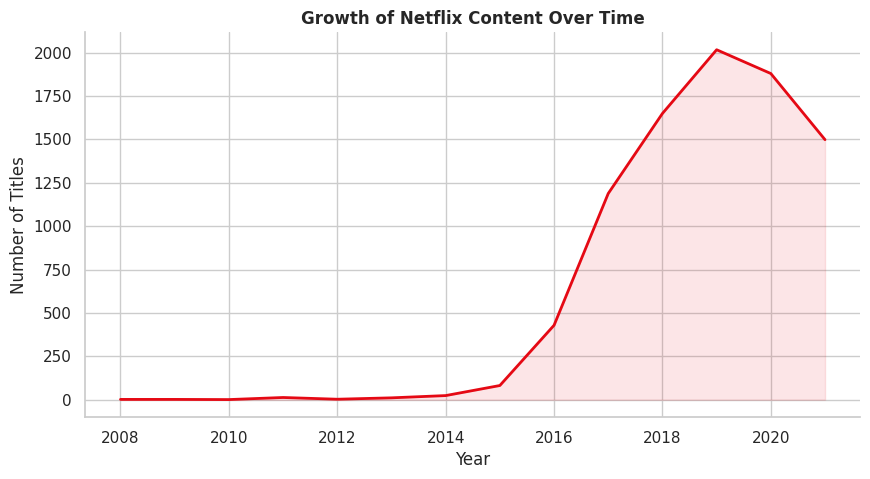

In [ ]:
year_counts = df['year_added'].value_counts().sort_index()

plt.plot(year_counts.index, year_counts.values, color=main_color, linewidth=2)
plt.fill_between(year_counts.index, year_counts.values, alpha=0.1, color=main_color)

plt.title("Growth of Netflix Content Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

sns.despine()
plt.show()

 Story -Growth of Netflix Content Over Time

 Netflix started slowly but fastly expanded after 2015, showing a major shift toward's content investment. This suggests the company scaled aggressively to compete in the streaming market and attract more audience.

 Derivation and Explanation:

 This  chart shows that Netflix content remained low until around 2015, after which there was a rapid increase, peaking in 2019. This reflects Netflix’s massive expansion strategy during that period. there is a slight decline after 2019 suggests a shift toward more selective content production.

The chart shows a sharp increase in content after 2015, indicating a strategic shift toward aggressive content expansion and original productions.

## Dominance of Movies Over TV Shows

/tmp/ipykernel_162/3373332919.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.index, y=type_counts.values,


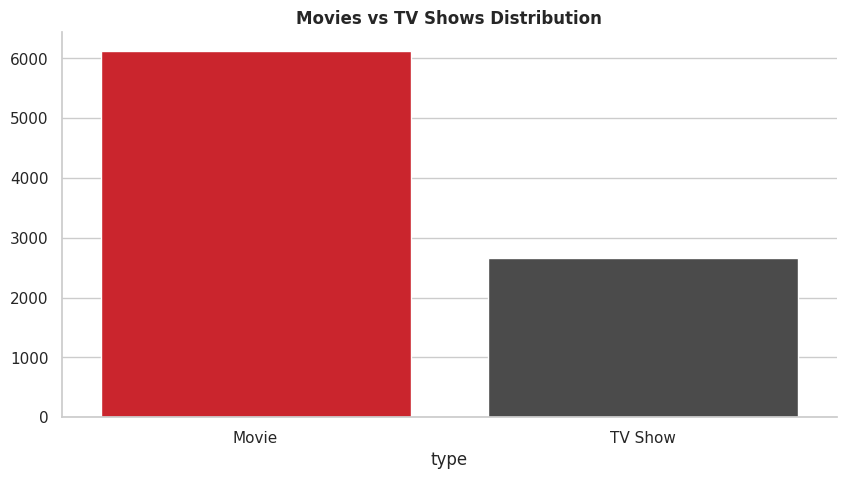

In [ ]:
type_counts = df['type'].value_counts()

sns.barplot(x=type_counts.index, y=type_counts.values,
            palette=[main_color, secondary_color])

plt.title("Movies vs TV Shows Distribution")
sns.despine()
plt.show()

Story - Movies vs TV Shows

Movies dominate Netflix’s library, but TV shows are growing steadily. This indicates Netflix is balancing quick-consumption content with longer series to improve audience engagement.

Derivation and Explanation:

This bar chart shows that movies significantly outnumber TV shows on Netflix. This indicates that the platform focuses more on movie content, likely because movies are quicker to produce and easier for users to consume compared to long TV series.

Movies significantly dominate Netflix’s catalog, suggesting a stronger focus on short-form content consumption.

## Content Production is Highly Concentrated

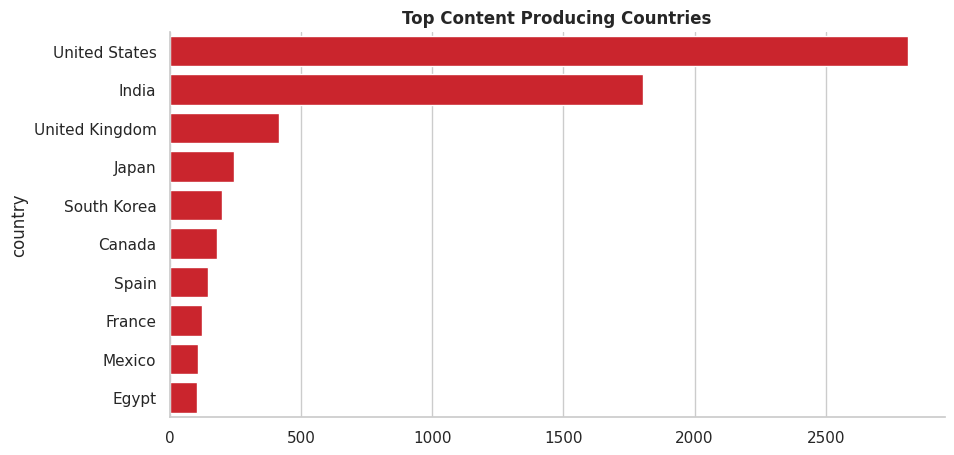

In [ ]:
top_countries = df['country'].value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index, color=main_color)

plt.title("Top Content Producing Countries")
sns.despine()
plt.show()

Story - Top Content Producing Countries

Most netflix content comes from the United States, with India and the UK contributing less. This shows Netflix relies heavily on a few regions, suggesting opportunities for global expansion.

Derivation and Explanation:

This horizontal bar chart shows the top content-producing countries on Netflix. The United States clearly dominates, producing significantly more content than any other country, followed by India. Other countries like the United Kingdom, Japan, and South Korea contribute much smaller amounts in comparison.

This indicates that Netflix content production is highly concentrated in a few countries, particularly the United States, while other regions play a smaller role.

The United States leads content production, highlighting geographic concentration and potential for international expansion.

## Genre Preferences on Netflix

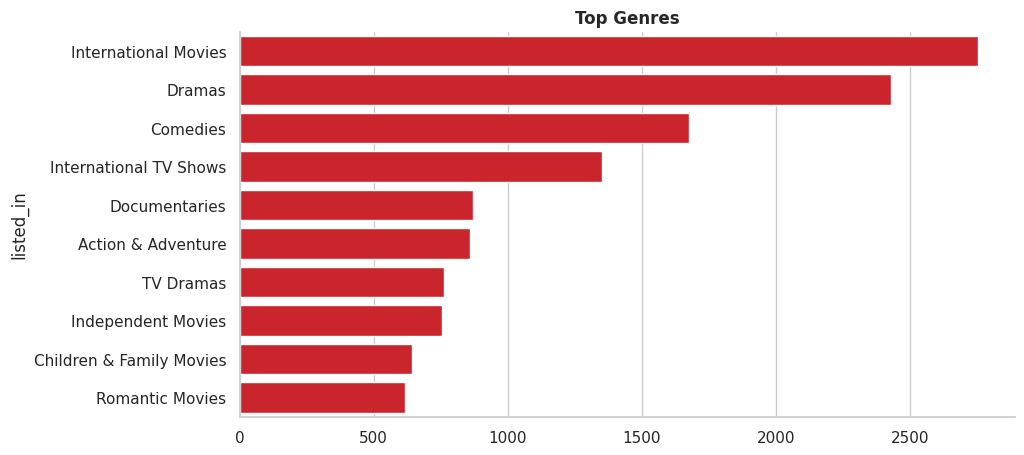

In [ ]:
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)

sns.barplot(x=top_genres.values, y=top_genres.index, color=main_color)

plt.title("Top Genres")
sns.despine()
plt.show()

Story - Top Genres

Genres like international movies and dramas dominate the platform. This reflects strong audience demand for globally diverse and emotionally engaging content.

Derivation and Explanation:

This horizontal bar chart shows the most common genres available on Netflix. International Movies and Dramas are the most dominant categories, followed by Comedies and International TV Shows. Other genres such as documentaries and action content appear less frequently.

This suggests that Netflix focuses heavily on globally diverse and drama-based content, reflecting strong audience demand for international and emotionally engaging storytelling.

Drama and international genres dominate, suggesting strong audience demand for emotionally engaging and globally diverse content.

## Optimal Movie Duration Range

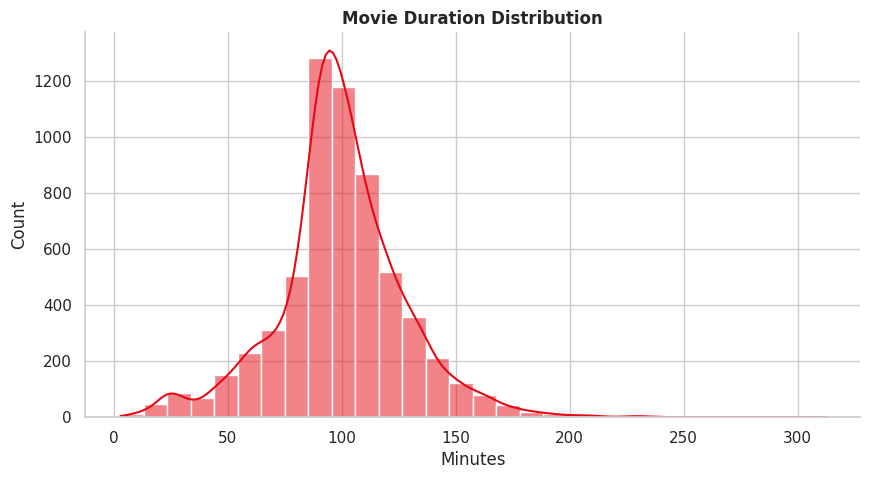

In [ ]:
sns.histplot(movies['duration_clean'].dropna(), bins=30, kde=True, color=main_color)

plt.title("Movie Duration Distribution")
plt.xlabel("Minutes")

sns.despine()
plt.show()

Story - Movie Duration Distribution

Most movies length is in between 90–120 minutes, showing a standard viewing preference. This suggests Netflix optimizes content length for audience comfort and engagement.

Derivation and Explanation:

The graph is derived by extracting numeric movie durations and visualizing their frequency distribution using a histogram with a density curve.

This graph shows the distribution of movie durations on Netflix. Most movies are concentrated between 90 and 120 minutes, forming a clear peak around this range. There are fewer movies with very short or very long durations, as shown by the lower frequencies at the edges.

This indicates that Netflix primarily offers movies within a standard duration range, likely because this length aligns with audience viewing preferences and maximizes engagement.

Most movies fall between 90–120 minutes, indicating a preferred standard duration for audience engagement.

## Seasonal Content Release Strategy

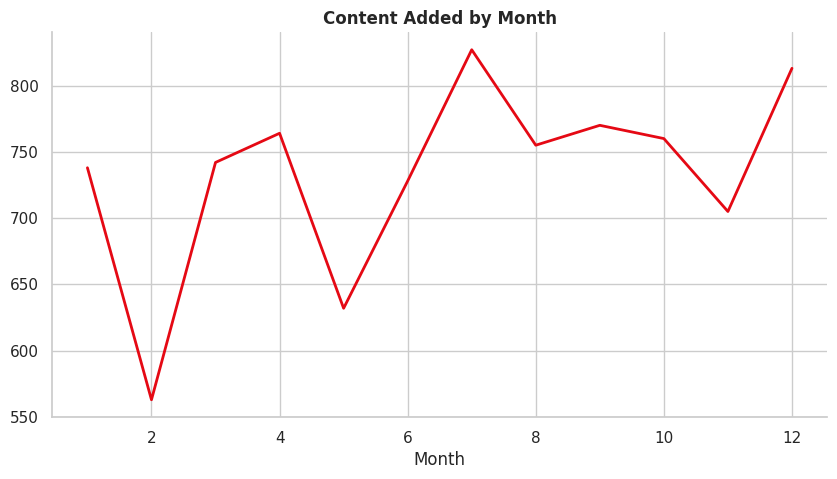

In [ ]:
month_counts = df['month_added'].value_counts().sort_index()

sns.lineplot(x=month_counts.index, y=month_counts.values,
             color=main_color, linewidth=2)

plt.title("Content Added by Month")
plt.xlabel("Month")

sns.despine()
plt.show()

Story - Content Added by Month

Some months show higher content additions than others, indicating a seasonal release strategy. Netflix likely plan  releases with peak viewing periods.

Derivation and Explanation:

The graph is created by extracting the month from the date_added column, then counting how many titles were added in each month. These counts are plotted across months to show trends.

This line chart shows how Netflix content additions vary by month. Some months (like July and December) have higher content additions, while others (like February) are lower. This suggests Netflix follows a seasonal release strategy, adding more content during peak viewing periods.


Content releases show seasonal patterns, suggesting strategic timing aligned with viewer demand cycles.

## Delay Between Production and Platform Release

/tmp/ipykernel_162/338831347.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='type', y='release_delay', data=df, palette=[main_color, secondary_color])


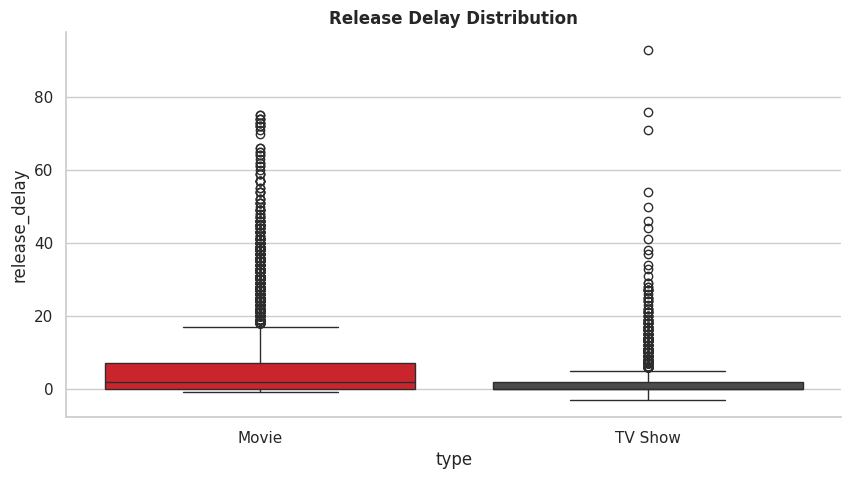

In [ ]:
df['release_delay'] = df['year_added'] - df['release_year']

sns.boxplot(x='type', y='release_delay', data=df, palette=[main_color, secondary_color])

plt.title("Release Delay Distribution")
sns.despine()
plt.show()

Story - Release Delay (Box Plot)

Most content is added soon after release, but some older titles appear later. This shows Netflix mixes new releases with older content to maintain variety.

Derivation and Explanation:

The graph is created by calculating the release delay, which is the difference between year_added and release_year. This value is then grouped by content type (Movie vs TV Show) and visualized using a box plot to show distribution.

Most content is added soon after release, but some older titles are added later. Movies show more variation than TV shows.

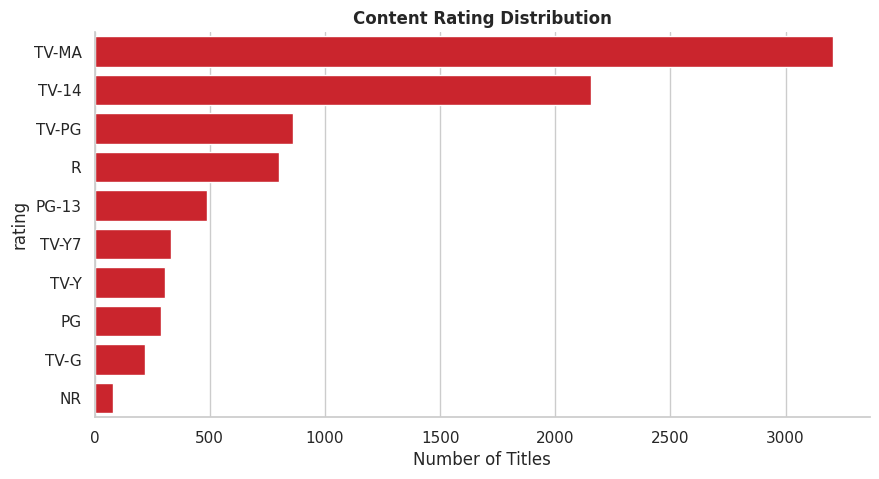

In [ ]:
rating_counts = df['rating'].value_counts().head(10)

sns.barplot(x=rating_counts.values, y=rating_counts.index, color=main_color)

plt.title("Content Rating Distribution")
plt.xlabel("Number of Titles")

sns.despine()
plt.show()

Story - Content Rating Distribution

Most content is rated TV-MA and TV-14, meaning Netflix focuses on mature and aged audiences. This highlights its strategy of targeting adult viewers over children.

Derivation and Explanation:

The graph is created by counting the number of titles in each rating category using the rating column.
These counts are then visualized using a horizontal bar chart for comparison.

The chart shows that TV-MA and TV-14 are the most common ratings on Netflix.
This indicates a strong focus on mature audience content compared to family or kids content.

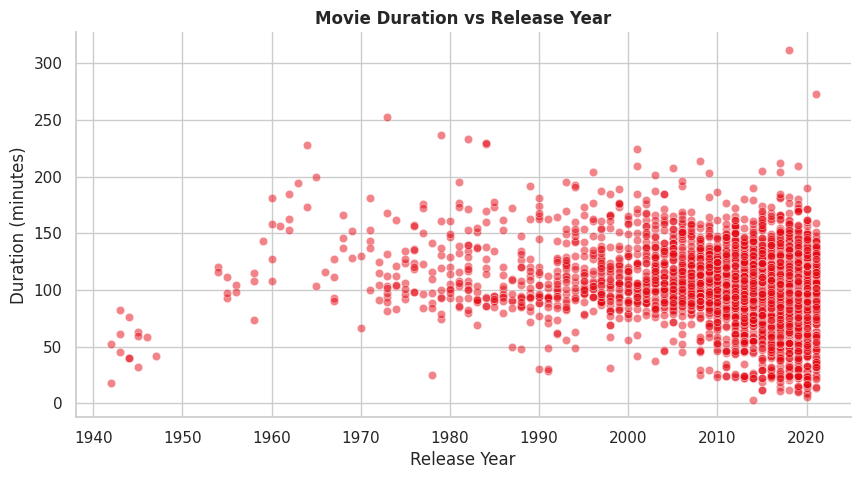

In [ ]:
sns.scatterplot(
    data=movies,
    x='release_year',
    y='duration_clean',
    alpha=0.5,
    color=main_color
)

plt.title("Movie Duration vs Release Year")
plt.xlabel("Release Year")
plt.ylabel("Duration (minutes)")

sns.despine()
plt.show()

Story - Movie Duration vs Release Year

Movie duration remains mostly consistent over time. This suggests audience preferences for movie length have not changed fastly.

Derivation and Explanation:

The graph is created by plotting release_year on the x-axis and duration_clean on the y-axis.
Each point represents a movie, showing the relationship between release year and duration.

The chart shows that most movie durations remain between 80–120 minutes across all years.
There is no strong trend over time, indicating consistent movie length preferences.

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_162/3838498903.py:1: SyntaxWarning: invalid escape sequence '\d'
  tv['seasons'] = tv['duration'].str.extract('(\d+)').astype(float)
/tmp/ipykernel_162/3838498903.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tv['seasons'] = tv['duration'].str.extract('(\d+)').astype(float)


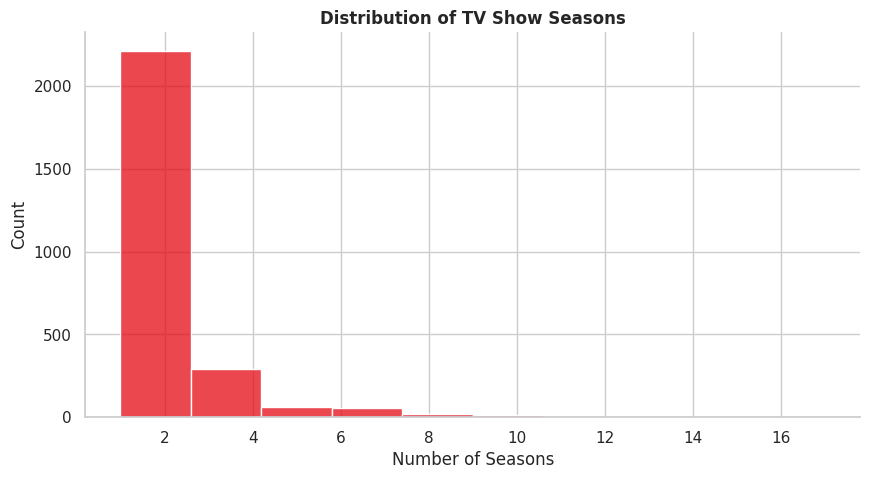

In [ ]:
tv['seasons'] = tv['duration'].str.extract('(\d+)').astype(float)

sns.histplot(tv['seasons'].dropna(), bins=10, color=main_color)

plt.title("Distribution of TV Show Seasons")
plt.xlabel("Number of Seasons")

sns.despine()
plt.show()

Story - TV Show Seasons Distribution

Most TV shows have only 1–2 seasons. This shows Netflix produces shorter series, possibly to reduce risk and test viewers interest.

Derivation and Explanation:

The graph is created by extracting the number of seasons from the duration column for TV shows.
These values are plotted using a histogram to show the frequency distribution of seasons.

Most TV shows have 1–2 seasons, with very few having many seasons.
This suggests Netflix content is mainly short series rather than long-running shows.

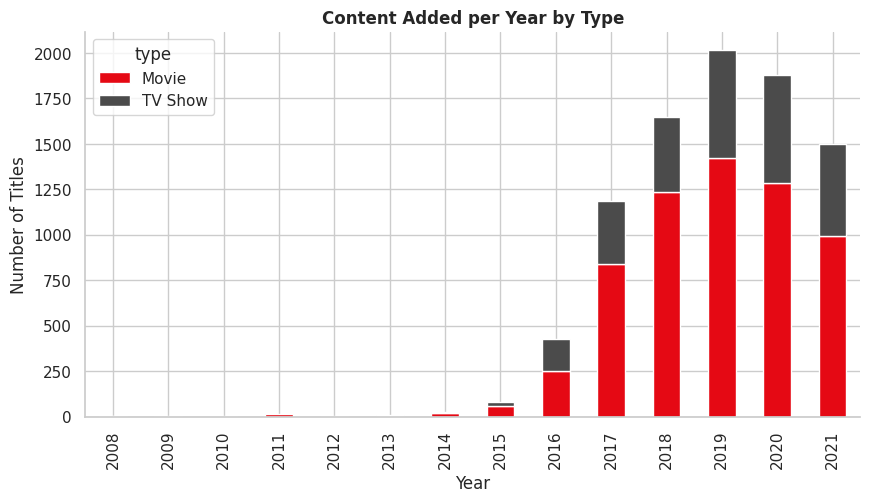

In [ ]:
type_year = df.groupby(['year_added', 'type']).size().unstack()

type_year.plot(kind='bar', stacked=True, color=[main_color, secondary_color])

plt.title("Content Added per Year by Type")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

sns.despine()
plt.show()

Story - Content Added per Year by Type

Content increased fastly after 2015, with movies leading and TV shows growing. This shows Netflix is gradually investing more in long-form content.

Derivation and explanation:

The graph is created by grouping data by year_added and type, then counting the number of titles.
These counts are plotted as a stacked bar chart to compare movies and TV shows over time.

The chart shows a rapid increase in content after 2015, with movies dominating but TV shows growing steadily.
This indicates Netflix is expanding its content library while gradually increasing focus on TV shows.

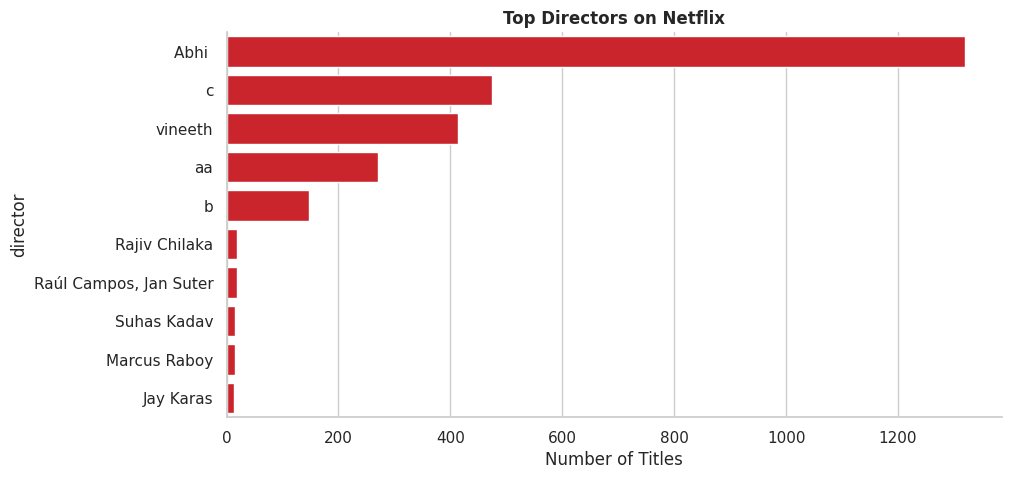

In [ ]:
top_directors = df['director'].value_counts().head(10)

sns.barplot(x=top_directors.values, y=top_directors.index, color=main_color)

plt.title("Top Directors on Netflix")
plt.xlabel("Number of Titles")

sns.despine()
plt.show()

Story - Top Directors

A small number of directors contribute many titles, while most directors contribute less. This suggests Netflix depends on key creators for consistent content production.

Derivation and Explanation:

The graph is created by counting the number of titles for each director using the director column.
The top directors are then selected and visualized using a horizontal bar chart.

The chart shows that a few directors contribute a large number of titles, while most contribute very few.
This indicates content production is concentrated among a small group of directors.

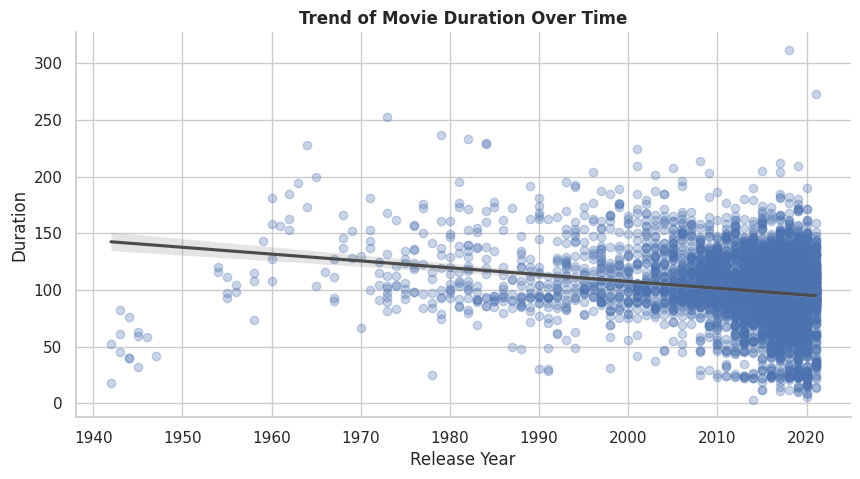

In [ ]:
sns.regplot(
    data=movies,
    x='release_year',
    y='duration_clean',
    scatter_kws={'alpha':0.3},
    line_kws={'color': secondary_color}
)

plt.title("Trend of Movie Duration Over Time")
plt.xlabel("Release Year")
plt.ylabel("Duration")

sns.despine()
plt.show()

**Story - Trend of Movie Duration Over Time**

There is a slight decrease in movie duration time over time. This may reflect changing viewer preferences toward shorter movies and more efficient content.

**Derivation and Explanation:**

The graph is created by plotting release_year against duration_clean for movies and applying a regression line.
This shows the relationship and overall trend of movie duration over time.

The chart shows a slight decrease in movie duration over the years, as indicated by the downward trend line.
This suggests a shift toward shorter movies, possibly to match changing audience preferences.


**Overall Insights and Implications**:

The analysis reveals that Netflix has experienced rapid growth in its content library, mainly after 2015, showing a significant expansion strategy. Movies continue to dominate the platform, even though TV shows are slowly increasing, suggesting a shift toward more engaging, long-format content. Additionally, content production is highly concentrated in some countries, particularly in  the United States, while genres such as drama and international content are very popular among audiences.
These findings show that Netflix focuses on scalable and globally engaging content while giving a balance between quantity and audience priorities. The consistent movie duration and dominance of adult-rated content further highlights a targeted approach toward adult viewers and their general viewing habits.

**Discussion (Project + Colab Work):**

This project has successfully developed an explanatory data analysis pipeline using Google Colab tool, with the combination of data preprocessing, visualization, and storytelling. The use of different visualization techniques such as bar charts, line charts, histograms, and scatter plots helps in presenting insights clear and effectively way. The workflow included handling null values, clearing inconsistent data formats (such as duration time and date fields), and updating variables to give meaningful analysis. The use of Python libraries like Pandas, Matplotlib, and Seaborn made it easy to generate clear and professional visualizations methods that support decision-making.

**Data Used:**

The analysis is based on a Netflix dataset, which includes information about movies and TV shows, other key attributes such as content type, country, release year, date added, genre, rating, and duration. Key preprocessing steps used: • Handling null values in columns such as country and director • Changing date fields into proper date and time format • Getting new features like year and month  Normalising duration into numerical values for helping analysis.



**Strengths of the Project:**

• Clean structure and well- designed code with explanations • Use of different chart types, enhancing insight diversity • Advanced data cleaning techniques and preprocessing steps • High use of storytelling methods to explain key insights • Professional and visually engaging and consistent graphs.




**Limitations of the Project:**

• The dataset had missing and incomplete values, which may affect the accuracy of the analysis • Analysis is constrained to available variables and does not include user other key attributes like behaviour or engagement data • Some insights are in descriptive format and does not establish normal relationships • Other important factors that affect content strategy are not considered.



**Data-Driven Recommendations:**

Based on the analysis, the below suggestions can be made: • Netflix should continuously invest in TV shows, as they are growing to improve long-term user engagement • Increase focus on global markets to reduce dependence on a few countries • Continuously producing drama and global content, as they are very popular • Maintain the standard movie time duration (90–120 minutes) to match viewer priorities. • Maximising release timing by aligning content drops with peak viewing months • Diversifying content ratings to attract a more audience, including family-friendly content and Rom-coms.

**Final Conclusion:**

In conclusion, this project shows how data visualization can be used to Derive meaningful insights from the real-world data. These findings highlight Netflix’s current content planning and provide correct recommendations for future decision-making process. By leveraging data-driven insights, Netflix can continue to improve its content variety and remain competitive in the streaming industry.
